In [1]:
import gzip
import json
import networkx
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
import seaborn as sns
import os

from matplotlib.backends.backend_pdf import PdfPages

from utils.io import load_analyzer, load_clustering, get_review_pmids
from utils.preprocessing import preprocess_clustering, get_clustering_level

sns.set();
%matplotlib inline

## Clustering Overview

### Visualize ground truth clustering and their intersections as a contingency matrix.

In [2]:
CLUSTERING_FOLDER = '/home/willenjoy/work/pubtrends/nature_reviews/clustering/'

In [ ]:
with PdfPages('clustering-overview.pdf') as pdf:
    for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
        full_filename = os.path.join(CLUSTERING_FOLDER, filename)
        with open(full_filename, 'r') as f:
            raw_clustering = json.load(f)
        for level in range(1, get_clustering_level(raw_clustering)):
            processed_clustering = preprocess_clustering(raw_clustering, level)
            n_clusters = len(processed_clustering)
            intersections = np.zeros((n_clusters, n_clusters))
            for i in range(n_clusters):
                for j in range(n_clusters):
                    common_elements = set(processed_clustering[i]).intersection(processed_clustering[j])
                    intersections[i, j] = len(common_elements)

            plt.figure(figsize = (10,7))
            sns.heatmap(intersections, annot=True)
            plt.title(f'{filename} - LEVEL {level}')
            pdf.savefig()
            plt.close()

### Ground Truth Cluster Size and Similarity Graph Density

In [2]:
MIN_COCITATION = 2
MIN_BIBCOUPLING = 0

In [3]:
def get_param_subgraph(graph, param, min_value=None):
    """
    Get a subgraph of a similarity graph that contains only edges with `param`.
    Optionally minimum value of `param` can be specified.
    """
    param_edges = list(filter(lambda el: param in el[2] and (not min_value or el[2][param] >= min_value), 
                              graph.edges(data=True)))
    param_subgraph = graph.edge_subgraph([(s, e) for s, e, d in param_edges])
    return param_subgraph

In [4]:
size_density_data = []

for pmid in get_review_pmids():
    analyzer = load_analyzer(pmid)
    clustering = load_clustering(pmid)
    for level in range(1, get_clustering_level(clustering)):
        ground_truth = preprocess_clustering(clustering, max_level=level,
                                             include_box_sections=False,
                                             uniqueness_method='unique_only')
        ground_truth_clusters = {comp: [] for comp in ground_truth.values()}
        for ref, c in ground_truth.items():
            ground_truth_clusters[c].append(ref)
        for c, refs in ground_truth_clusters.items():
            cluster_similarity_subgraph = analyzer.similarity_graph.subgraph(refs)
            
            param_densities = []
            for param, min_value in zip(['cocitation', 'cocitation', 'bibcoupling', 'citation', 'text'], [0, 2, 0, 0, 0]):
                param_subgraph = get_param_subgraph(cluster_similarity_subgraph, param, min_value)
                param_densities.append(networkx.density(param_subgraph))
            size_density_data.append((pmid, level, 
                                      len(refs) / len(ground_truth), 
                                      networkx.density(cluster_similarity_subgraph),
                                      *param_densities))

In [5]:
size_density_df = pd.DataFrame(size_density_data, 
                               columns=['PMID', 'Level', 'Relative Size',
                                        'Overall Density', 'Cocitation Density', 
                                        'Cocitation (min=2) Density', 'Bibcoupling Density',
                                        'Citation Density', 'Text Citation Density']).apply(pd.to_numeric, errors='coerce')

In [6]:
size_density_df.head(5)

,PMID,Level,Relative Size,Overall Density,Cocitation Density,Cocitation (min=2) Density,Bibcoupling Density,Citation Density,Text Citation Density
0,26580716,1,0.230159,1.0,1.0,0.578348,0.641026,0.104762,0.178571
1,26580716,1,0.174603,1.0,1.0,0.658009,0.833333,0.186813,0.200000
2,26580716,1,0.119048,1.0,1.0,0.552381,0.777778,0.294872,0.380952
3,26580716,1,0.071429,1.0,1.0,0.777778,0.809524,0.250000,1.000000
4,26580716,1,0.079365,1.0,1.0,0.511111,1.000000,0.466667,0.000000


In [7]:
size_density_df.max()

PMID                          3.269929e+07
Level                         3.000000e+00
Relative Size                 6.991870e-01
Overall Density               1.166667e+00
Cocitation Density            1.000000e+00
Cocitation (min=2) Density    1.000000e+00
Bibcoupling Density           1.000000e+00
Citation Density              2.000000e+00
Text Citation Density         1.000000e+00
dtype: float64

#### Relative Cluster Size vs Densities of Subgraphs for Different Parameters

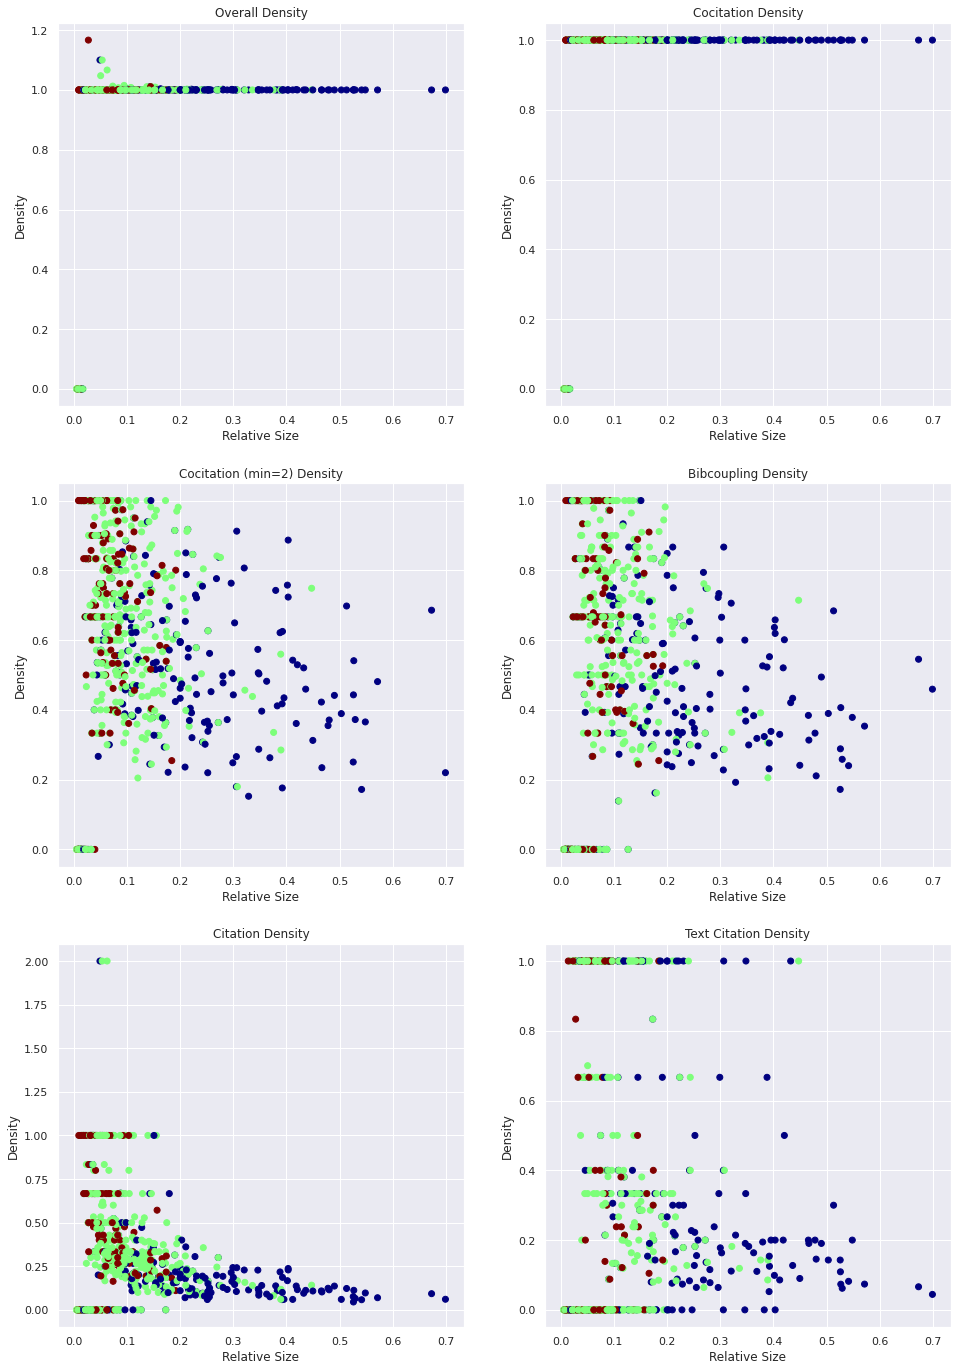

In [8]:
fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(16, 24))

for ax, param in zip([ax1, ax2, ax3, ax4, ax5, ax6], 
                     ['Overall Density', 'Cocitation Density', 
                      'Cocitation (min=2) Density', 'Bibcoupling Density', 
                      'Citation Density', 'Text Citation Density']):
    sc = ax.scatter(x=size_density_df["Relative Size"], y=size_density_df[param], 
                    c=size_density_df["Level"], cmap='jet')
    ax.set_xlabel('Relative Size')
    ax.set_ylabel('Density');
    ax.set_title(param)

#### Correlation of Subgraph Density for Different Parameters

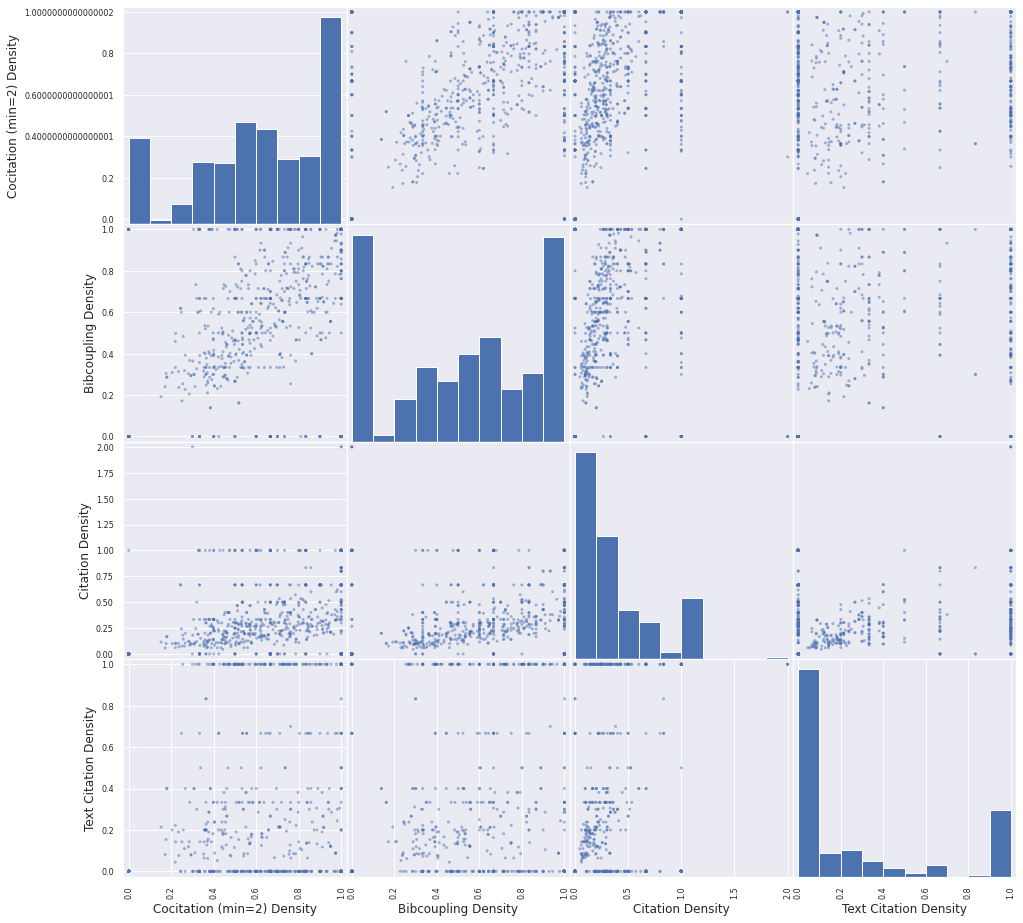

In [11]:
pd.plotting.scatter_matrix(size_density_df[['Cocitation (min=2) Density', 'Bibcoupling Density', 
                                            'Citation Density', 'Text Citation Density']],
                           figsize=(16, 16));

### References Subgraph Density (with min=2 for Cocitation, otherwise does not make sense)

In [ ]:
refs_density_data = []
overall_density_data = []

for pmid in get_review_pmids():
    analyzer = load_analyzer(pmid)
    overall_density_data.append(networkx.density(analyzer.similarity_graph))
    
    clustering = load_clustering(pmid)
    for level in range(1, get_clustering_level(clustering)):
        ground_truth = preprocess_clustering(clustering, max_level=level,
                                             include_box_sections=False,
                                             uniqueness_method='unique_only')
        references_subgraph = analyzer.similarity_graph.subgraph(ground_truth.keys())
        
        # Filter out edges with cocitation = 1
        good_edges = list(filter(lambda el: 'cocitation' not in el[2] or el[2]['cocitation'] >= 2, 
                                 references_subgraph.edges(data=True)))
        good_subgraph = references_subgraph.edge_subgraph([(s, e) for s, e, d in good_edges])
        
        n_references = good_subgraph.number_of_nodes()
        refs_density_data.append(networkx.density(good_subgraph))
#         print(pmid, level, n_references * (n_references - 1) / 2, good_subgraph.number_of_edges())

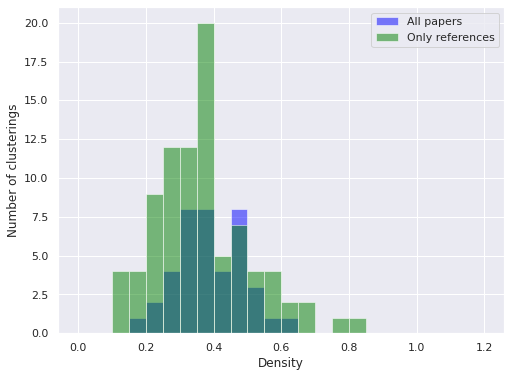

In [15]:
plt.figure(figsize=(8, 6))
bins = np.linspace(0.0, 1.2, 25)
plt.hist(overall_density_data, bins, color='blue', alpha=0.5, label='All papers')
plt.hist(refs_density_data, bins, color='green', alpha=0.5, label='Only references')
plt.xlabel('Density')
plt.ylabel('Number of clusterings')
plt.legend();

## PubTrends Export Overview

### Prior vs. Derivative Papers

In [93]:
year_diffs = []

for pmid in get_review_pmids():
    analyzer = load_analyzer(pmid)
    review_row = analyzer.df[analyzer.df.id == pmid]
    review_year = review_row['year'].values[0]
    ref_year_diffs = analyzer.df['year'].drop(review_row.index) - review_year
    year_diffs.extend(list(ref_year_diffs.values))

In [91]:
max(year_diffs)

3

Text(0, 0.5, 'Amount of Papers')

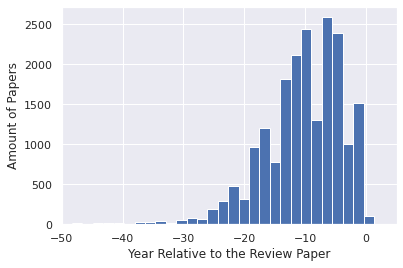

In [89]:
plt.hist(year_diffs, bins=100)
plt.xlim([-50, 5])
plt.xlabel('Year Relative to the Review Paper')
plt.ylabel('Amount of Papers')

### Direct Citations Count

In [16]:
total_review_citations = 0
total_review_total = 0

for pmid in get_review_pmids():
    analyzer = load_analyzer(pmid)
    review_row = analyzer.df[analyzer.df.id == pmid]
    review_citations = len(list(analyzer.citations_graph.predecessors(pmid)))
    review_total = review_row['total'].values[0]
    total_review_citations += review_citations
    total_review_total += review_total
    
print('Review citations included in the analysis:', total_review_citations)
print('Total citation count of all reviews:', total_review_total)

Review citations included in the analysis: 3
Total citation count of all reviews: 3499


### Edge Count and Weight Distribution

In [28]:
def rebuild_similarity_graph(analyzer):
    analyzer.ids = set(analyzer.df['id'])
    analyzer.n_papers = len(analyzer.ids)
    analyzer.pub_types = list(set(analyzer.df['type']))
    analyzer.query = 'restored from PubTrends export'
    
    PUB_DF_COLUMNS = ['id', 'title', 'abstract', 'year', 'type', 'keywords', 'mesh', 'doi', 'aux']
    analyzer.pub_df = analyzer.df[PUB_DF_COLUMNS]
    
    analyzer.components = set(analyzer.df['comp'].unique())
    if -1 in analyzer.components:
        analyzer.components.remove(-1)
        
    settings = AnalyzerSettings()
    analyzer.corpus_ngrams, analyzer.corpus_counts = \
        vectorize_corpus(analyzer.pub_df,
                         max_features=settings.VECTOR_WORDS, n_gram=settings.VECTOR_NGRAMS,
                         min_df=settings.VECTOR_MIN_DF, max_df=settings.VECTOR_MAX_DF)
    tfidf = compute_tfidf(analyzer.corpus_counts)
    analyzer.texts_similarity = analyzer.analyze_texts_similarity(analyzer.pub_df, tfidf,
                                                                  settings.SIMILARITY_TEXT_MIN,
                                                                  settings.SIMILARITY_TEXT_CITATION_N)
    
    cocit_data = []
    bibcoupling_data = []
    for cited_1, cited_2, data in analyzer.similarity_graph.edges(data=True):
        if 'cocitation' in data:
            cocit_data.append((cited_1, cited_2, data['cocitation']))
        if 'bibcoupling' in data:
            bibcoupling_data.append((cited_1, cited_2, data['bibcoupling']))
            
    cocit_df = pd.DataFrame(cocit_data, columns=['cited_1', 'cited_2', 'total'])
    bibcoupling_df = pd.DataFrame(bibcoupling_data, columns=['citing_1', 'citing_2', 'total'])
    
    analyzer.similarity_graph = analyzer.build_similarity_graph(
        analyzer.df, analyzer.texts_similarity,
        analyzer.citations_graph, cocit_df, bibcoupling_df,
        current=0, task=None
    )

In [21]:
with PdfPages('pubtrends-similarity-parameters-scaled-hist.pdf') as pdf:
    for filename in sorted(os.listdir(PUBTRENDS_EXPORT_FOLDER)):
        analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, filename)
        analyzer = reload_exported_analyzer(analysis_file)
        rebuild_similarity_graph(analyzer)
        stats = {
            'cocitation': [],
            'bibcoupling': [],
            'citation': [],
            'text': []
        }
        for _, _, data in analyzer.similarity_graph.edges(data=True):
            for key in stats.keys():
                stats[key].append(data.get(key, 0))

        stats_df = pd.DataFrame(stats).apply(pd.to_numeric, errors='coerce')
        ax = stats_df.hist(log=True)
        plt.suptitle(filename)
        pdf.savefig()
        plt.close()

In [33]:
full_stats = {
    'cocitation': [],
    'bibcoupling': [],
    'citation': [],
    'text': []
}

from utils.analysis import reload_exported_analyzer

for filename in sorted(os.listdir(PUBTRENDS_EXPORT_FOLDER)):
    analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, filename)
    analyzer = reload_exported_analyzer(analysis_file)
    
    stats = {
        'cocitation': 0,
        'bibcoupling': 0,
        'citation': 0,
        'text': 0
    }
    
    for _, _, data in analyzer.similarity_graph.edges(data=True):
        for key in stats.keys():
            if key in data:
                stats[key] += 1
    
    for key in stats:
        full_stats[key].append(stats[key])
    
    print(filename, analyzer.similarity_graph.number_of_edges(), stats)

26580716.json.gz 38594 {'cocitation': 36745, 'bibcoupling': 6052, 'citation': 2020, 'text': 235}
26580717.json.gz 58892 {'cocitation': 49507, 'bibcoupling': 18098, 'citation': 2655, 'text': 223}
26656254.json.gz 34795 {'cocitation': 33179, 'bibcoupling': 4413, 'citation': 1772, 'text': 203}
26667849.json.gz 39173 {'cocitation': 34929, 'bibcoupling': 8507, 'citation': 1528, 'text': 264}
26675821.json.gz 22088 {'cocitation': 20779, 'bibcoupling': 2538, 'citation': 1165, 'text': 137}
26678314.json.gz 45447 {'cocitation': 44796, 'bibcoupling': 2318, 'citation': 1155, 'text': 230}
26688349.json.gz 66479 {'cocitation': 63832, 'bibcoupling': 12288, 'citation': 2947, 'text': 234}
26688350.json.gz 58017 {'cocitation': 54122, 'bibcoupling': 13324, 'citation': 2898, 'text': 127}
27677859.json.gz 33268 {'cocitation': 29915, 'bibcoupling': 6952, 'citation': 1556, 'text': 111}
27677860.json.gz 54879 {'cocitation': 52771, 'bibcoupling': 11543, 'citation': 2862, 'text': 157}
27834397.json.gz 51408 {'c

In [34]:
full_stats_df = pd.DataFrame(full_stats).apply(pd.to_numeric, errors='coerce')

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f00e968d7c0>,
      dtype=object)

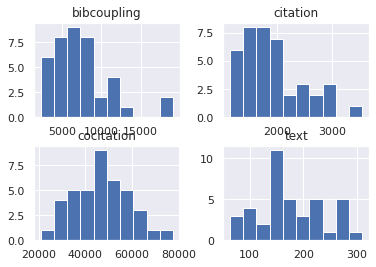

In [38]:
full_stats_df.hist()

## DEPRECATED: Estimate PubTrends quality for different clusterings

In [22]:
from pysrc.papers.analyzer import KeyPaperAnalyzer
from pysrc.papers.pubtrends_config import PubtrendsConfig, AnalyzerSettings
from pysrc.papers.db.loaders import Loaders
from pysrc.papers.utils import vectorize_corpus, compute_tfidf

from sklearn.metrics.cluster import adjusted_rand_score, v_measure_score, \
                                    adjusted_mutual_info_score, contingency_matrix
from sklearn.metrics import fowlkes_mallows_score

In [23]:
PUBTRENDS_EXPORT_FOLDER = '/home/willenjoy/work/pubtrends/nature_reviews/pubtrends_export/'
PUBTRENDS_CONFIG = PubtrendsConfig(test=False)

In [ ]:
def get_clustering(analyzer, target_ids):
    data = analyzer.df[analyzer.df['id'].isin(target_ids)]
    return {k: v for k, v in zip(data['id'], data['comp'])}

In [ ]:
def evaluate_clustering(analyzer, ground_truth, metric):
    actual_clustering = get_clustering(analyzer, ground_truth.keys())
    
    # Align clusterings
    labels_true = []
    labels_pred = []

    for pmid in actual_clustering:
        labels_true.append(ground_truth[pmid])
        labels_pred.append(actual_clustering[pmid])
        
    return metric(labels_true, labels_pred), contingency_matrix(labels_true, labels_pred)

In [ ]:
def estimate_quality(metric, uniqueness_method, include_box_sections):
    pmids = []
    levels = []
    scores = []
    for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
        pmid, _ = os.path.splitext(filename)
        full_filename = os.path.join(CLUSTERING_FOLDER, filename)
        with open(full_filename, 'r') as f:
            raw_clustering = json.load(f)
        analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
        analyzer = reload_exported_analyzer(analysis_file)
        for level in range(1, get_clustering_level(raw_clustering)):
            processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                         include_box_sections=include_box_sections)
            ground_truth = unique_ids_clustering(processed_clustering, method=uniqueness_method)
            score, _ = evaluate_clustering(analyzer, ground_truth, metric)
            print(pmid, level, score)
            pmids.append(pmid)
            levels.append(level)
            scores.append(score)
            
    return pmids, levels, scores 

In [ ]:
COLOR_MAP = {1: '#455cf5', 2: '#33e836', 3: '#eb5021'}

In [ ]:
scores_by_metric = {}

with PdfPages('pubtrends-quality.pdf') as pdf:
    for metric in [adjusted_rand_score, adjusted_mutual_info_score, v_measure_score, fowlkes_mallows_score]:
        for uniqueness_method in ['first_occurrence', 'unique_only']:
            for include_box_sections in [True, False]:
                print(metric.__name__, uniqueness_method, include_box_sections)
                pmids, levels, scores = estimate_quality(metric, uniqueness_method, include_box_sections)
                
                # Visualize
                colors = [COLOR_MAP[l] for l in levels]
    
                plt.figure(figsize=(10, 7))
                plt.scatter(pmids, scores, c=colors)
                plt.title(f'unique: {uniqueness_method} - include_box_sections: {include_box_sections}')
                plt.xlabel('PMID')
                plt.ylabel(metric.__name__)
                plt.xticks(rotation = 90)
                pdf.savefig()
                plt.close()
                
                if metric.__name__ not in scores_by_metric:
                    scores_by_metric[metric.__name__] = scores
                else:
                    scores_by_metric[metric.__name__].append(scores)

In [ ]:
import pandas as pd
from pandas.plotting import scatter_matrix

In [ ]:
scores_df = pd.DataFrame(scores_by_metric).apply(pd.to_numeric, errors='coerce')

In [ ]:
scatter_matrix(scores_df, alpha=0.8, grid=True, figsize=(15, 15))

In [ ]:
scores_df.head()

### Visualize Contingency Matrices for Default PubTrends Settings

In [ ]:
METRIC_ALIAS = {
    'adjusted_rand_score': 'Rand',
    'adjusted_mutual_info_score': 'Mutual-Info',
    'v_measure_score': 'V-Measure',
    'fowlkes_mallows_score': 'Fowlkes-Mallows'
}

with PdfPages('pubtrends-contingency-matrices.pdf') as pdf:
    for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
        pmid, _ = os.path.splitext(filename)
        full_filename = os.path.join(CLUSTERING_FOLDER, filename)
        with open(full_filename, 'r') as f:
            raw_clustering = json.load(f)
        analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
        analyzer = reload_exported_analyzer(analysis_file)
        for level in range(1, get_clustering_level(raw_clustering)):
            processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                         include_box_sections=False)
            ground_truth = unique_ids_clustering(processed_clustering, method='unique_only')
            
            scores = {}
            for metric in [adjusted_rand_score, adjusted_mutual_info_score, 
                           v_measure_score, fowlkes_mallows_score]:
                scores[metric.__name__], cm = evaluate_clustering(analyzer, ground_truth, metric)
            
            metrics_str = ", ".join([f'{METRIC_ALIAS[k]}: {v:.2f}' for k, v in scores.items()])
            plt.figure(figsize = (10,7))
            sns.heatmap(cm, annot=True)
            plt.title(f'{filename} - LEVEL {level}\n{metrics_str}')
            plt.xlabel('PubTrends')
            plt.ylabel('Nature Reviews')
            pdf.savefig()
            plt.close()

### Topic Analysis Only for Subgraph (Direct Reference Papers, One of the Subtopics, etc)

In [26]:
def get_direct_references_subgraph(analyzer, pmid):
    references = list(analyzer.citations_graph.successors(pmid))
    references.append(pmid)
    
    references_similarity_graph = analyzer.similarity_graph.subgraph(references)
    return references_similarity_graph

In [ ]:
from collections import Counter

def get_most_references_subtopic_subgraph(analyzer, pmid):
    references = list(analyzer.citations_graph.successors(pmid))
    reference_comps = analyzer.df[analyzer.df['id'].isin(references)]['comp'].values
    subtopic_id = Counter(reference_comps).most_common(1)[0][0]
    subtopic_papers = analyzer.df[analyzer.df['comp'] == subtopic_id]['id'].values
    
    subtopic_subgraph = analyzer.similarity_graph.subgraph(subtopic_papers)
    return subtopic_subgraph

In [43]:
def evaluate_clustering_for_partition(partition, ground_truth, pmid, metric):
    # Get clustering
    actual_clustering = {k: v for k, v in partition.items() if k in ground_truth}
    
    # Align clusterings
    labels_true = []
    labels_pred = []

    for pmid in actual_clustering:
        labels_true.append(ground_truth[pmid])
        labels_pred.append(actual_clustering[pmid])
        
    return metric(labels_true, labels_pred), contingency_matrix(labels_true, labels_pred)

In [44]:
def recalculate_topic_analysis(analyzer, graph=None, settings=AnalyzerSettings()):
    if not graph:
        graph = analyzer.similarity_graph
    topics_dendrogram, partition, comp_other, components, comp_sizes = \
                analyzer.topic_analysis(graph,
                                        topic_min_size=settings.TOPIC_MIN_SIZE,
                                        max_topics_number=settings.TOPICS_MAX_NUMBER,
                                        random_state=settings.SEED,
                                        similarity_bibliographic_coupling=settings.SIMILARITY_BIBLIOGRAPHIC_COUPLING,
                                        similarity_cocitation=settings.SIMILARITY_COCITATION,
                                        similarity_citation=settings.SIMILARITY_CITATION,
                                        similarity_text_citation=settings.SIMILARITY_TEXT_CITATION)
    return partition

#### Direct References

In [ ]:
METRIC_ALIAS = {
    'adjusted_rand_score': 'Rand',
    'adjusted_mutual_info_score': 'Mutual-Info',
    'v_measure_score': 'V-Measure',
    'fowlkes_mallows_score': 'Fowlkes-Mallows'
}

with PdfPages('pubtrends-contingency-matrices-refs-only.pdf') as pdf:
    for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
        pmid, _ = os.path.splitext(filename)
        full_filename = os.path.join(CLUSTERING_FOLDER, filename)
        with open(full_filename, 'r') as f:
            raw_clustering = json.load(f)
        analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
        analyzer = reload_exported_analyzer(analysis_file)
        direct_references_subgraph = get_direct_references_subgraph(analyzer, pmid)
        partition = recalculate_topic_analysis(analyzer, direct_references_subgraph)
        for level in range(1, get_clustering_level(raw_clustering)):
            processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                         include_box_sections=False)
            ground_truth = unique_ids_clustering(processed_clustering, method='unique_only')
            
            scores = {}
            for metric in [adjusted_rand_score, adjusted_mutual_info_score, 
                           v_measure_score, fowlkes_mallows_score]:
                scores[metric.__name__], cm = evaluate_clustering_for_partition(partition, 
                                                                                ground_truth, 
                                                                                pmid, metric)
            
            metrics_str = ", ".join([f'{METRIC_ALIAS[k]}: {v:.2f}' for k, v in scores.items()])
            plt.figure(figsize = (10,7))
            sns.heatmap(cm, annot=True)
            plt.title(f'{filename} - LEVEL {level}\n{metrics_str}')
            plt.xlabel('PubTrends')
            plt.ylabel('Nature Reviews')
            pdf.savefig()
            plt.close()

#### The Biggest Subtopic

In [ ]:
METRIC_ALIAS = {
    'adjusted_rand_score': 'Rand',
    'adjusted_mutual_info_score': 'Mutual-Info',
    'v_measure_score': 'V-Measure',
    'fowlkes_mallows_score': 'Fowlkes-Mallows'
}

with PdfPages('pubtrends-contingency-matrices-biggest-subtopic.pdf') as pdf:
    for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
        pmid, _ = os.path.splitext(filename)
        full_filename = os.path.join(CLUSTERING_FOLDER, filename)
        with open(full_filename, 'r') as f:
            raw_clustering = json.load(f)
        analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
        analyzer = reload_exported_analyzer(analysis_file)
        subtopic_subgraph = get_most_references_subtopic_subgraph(analyzer, pmid)
        if not subtopic_subgraph:
            print('Bad subgraph')
        partition = recalculate_topic_analysis(analyzer, subtopic_subgraph)
        for level in range(1, get_clustering_level(raw_clustering)):
            processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                         include_box_sections=False)
            ground_truth = unique_ids_clustering(processed_clustering, method='unique_only')
            
            scores = {}
            for metric in [adjusted_rand_score, adjusted_mutual_info_score, 
                           v_measure_score, fowlkes_mallows_score]:
                scores[metric.__name__], cm = evaluate_clustering_for_partition(partition, 
                                                                                ground_truth, 
                                                                                pmid, metric)
            
            metrics_str = ", ".join([f'{METRIC_ALIAS[k]}: {v:.2f}' for k, v in scores.items()])
            plt.figure(figsize = (10,7))
            sns.heatmap(cm, annot=True)
            plt.title(f'{filename} - LEVEL {level}\n{metrics_str}')
            plt.xlabel('PubTrends')
            plt.ylabel('Nature Reviews')
            pdf.savefig()
            plt.close()

### PubTrends Cluster Sizes

TODO: compare with only-refs setting

In [ ]:
from collections import Counter

for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
    pmid, _ = os.path.splitext(filename)
    full_filename = os.path.join(CLUSTERING_FOLDER, filename)
    with open(full_filename, 'r') as f:
        raw_clustering = json.load(f)
    analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
    analyzer = reload_exported_analyzer(analysis_file)
    processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                 include_box_sections=False)
    ground_truth = unique_ids_clustering(processed_clustering, method='unique_only')
    actual_clustering = get_clustering(analyzer, ground_truth.keys()).values()
    comp_sizes = Counter(actual_clustering).most_common(3)
    n_papers = len(actual_clustering)
    scaled_sizes = [v * 100 / n_papers for comp, v in comp_sizes]
    print(f"{pmid}\t{scaled_sizes}")

## Run Grid Search for Analyzer Parameters

In [29]:
import itertools
import logging

In [30]:
logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)s: %(message)s')

In [31]:
param_grid = {
    'SIMILARITY_BIBLIOGRAPHIC_COUPLING': [0.125, 0.25, 0.5, 1, 2, 4, 8],
#     'SIMILARITY_COCITATION': [0.125, 0.25, 0.5, 1, 2, 4, 8],
#     'SIMILARITY_CITATION': [0.125, 0.25, 0.5, 1, 2, 4, 8],
    'SIMILARITY_TEXT_CITATION': [0.125, 0.25, 0.5, 1, 2, 4, 8]
}

In [70]:
def settings_of_interest(analyzer_settings):
    return (
        analyzer_settings.SIMILARITY_BIBLIOGRAPHIC_COUPLING,
        analyzer_settings.SIMILARITY_COCITATION,
#         analyzer_settings.SIMILARITY_CITATION,
        analyzer_settings.SIMILARITY_TEXT_CITATION,
    )

In [63]:
baseline_params = dict(
    TOPIC_MIN_SIZE=0,
    TOPICS_MAX_NUMBER=500,
    SIMILARITY_CITATION=0,
    SIMILARITY_COCITATION=1
)

In [28]:
TARGET_METRIC = v_measure_score.__name__

In [81]:
param_names = param_grid.keys()
results = {}

for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
    pmid, _ = os.path.splitext(filename)
    full_filename = os.path.join(CLUSTERING_FOLDER, filename)
    with open(full_filename, 'r') as f:
        raw_clustering = json.load(f)
    analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
    analyzer = reload_exported_analyzer(analysis_file)
    logging.info(f'{pmid} - loaded clustering and analyzer')
    rebuild_similarity_graph(analyzer)
    direct_references_subgraph = get_direct_references_subgraph(analyzer, pmid)
    logging.info(f'{pmid} - rebuilt similarity graph with scaling')
    
    for level in range(1, get_clustering_level(raw_clustering)):
        processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                     include_box_sections=False)
        ground_truth = unique_ids_clustering(processed_clustering, method='unique_only')
        logging.info(f'{pmid} level {level} - calculated ground truth clustering')
        
        best_score = 0
        best_soi = None
        grid_results = {}
        
        logging.info(f'{pmid} level {level} - starting grid search')
    
        # Iterate over param grid
        for param_values in itertools.product(*param_grid.values()):
            params = {k: v for k, v in zip(param_names, param_values)}
            for k, v in baseline_params.items():
                params[k] = v

            # Apply settings and recalculate 
            settings = AnalyzerSettings(**params)
            soi = settings_of_interest(settings)
            partition = recalculate_topic_analysis(analyzer, 
                                                   graph=direct_references_subgraph,
                                                   settings=settings)

            result = {}
            for metric in [adjusted_rand_score, adjusted_mutual_info_score, 
                           v_measure_score, fowlkes_mallows_score]:
                result[metric.__name__], _ = evaluate_clustering_for_partition(partition, 
                                                                               ground_truth, 
                                                                               pmid, metric)
            result['partition'] = partition
            grid_results[soi] = result
            
            n_comps = len(set(partition.values()))
            new_best = False
            if result[TARGET_METRIC] > best_score:
                best_score = result[TARGET_METRIC]
                best_soi = soi
                new_best = True

            score_str = f"{'BEST' if new_best else '    '} {result[TARGET_METRIC]}" 
            print(soi, score_str, n_comps, sep='\t')
            
        logging.info(f'{pmid} level {level} - best score {best_score} for params {best_soi}')
        best_partition = grid_results[best_soi]['partition']
        _, cm = evaluate_clustering_for_partition(partition, ground_truth, pmid, metric)
        logging.info('Best partition')
        print(cm)
        
        results[(pmid, level)] = {
            'best_score': best_score,
            'best_soi': best_soi,
            'grid': grid_results
        }

2021-02-10 00:03:12,061 INFO: 26580716 - loaded clustering and analyzer
2021-02-10 00:03:12,065 INFO: Building corpus from 500 papers
2021-02-10 00:03:12,153 INFO: Corpus size: 4264 bytes
2021-02-10 00:03:36,055 INFO: Building papers similarity graph
2021-02-10 00:03:36,474 INFO: Citations based graph - 500 nodes and 38588 edges
2021-02-10 00:03:36,485 INFO: Built full similarity graph - 500 nodes and 38594 edges
2021-02-10 00:03:36,578 INFO: 26580716 - rebuilt similarity graph with scaling
2021-02-10 00:03:36,580 INFO: 26580716 level 1 - calculated ground truth clustering
2021-02-10 00:03:36,583 INFO: 26580716 level 1 - starting grid search


(0.125, 1, 0.125)	BEST 0.40049311832128454	7
(0.125, 1, 0.25)	     0.40049311832128454	7
(0.125, 1, 0.5)	     0.39972746152348054	6
(0.125, 1, 1)	     0.36714548467899266	7
(0.125, 1, 2)	BEST 0.41511507458313285	11
(0.125, 1, 4)	     0.41226507618777086	13
(0.125, 1, 8)	     0.35618000662972554	17
(0.25, 1, 0.125)	     0.4027834048821059	6
(0.25, 1, 0.25)	     0.4027834048821059	6
(0.25, 1, 0.5)	     0.4122631030399456	6
(0.25, 1, 1)	BEST 0.4392209970121744	7
(0.25, 1, 2)	     0.43056719190538884	10
(0.25, 1, 4)	     0.424867256568994	12
(0.25, 1, 8)	     0.39920932865697983	17
(0.5, 1, 0.125)	     0.3889182679487781	7
(0.5, 1, 0.25)	     0.40312937587343567	7
(0.5, 1, 0.5)	     0.39542080860766915	7
(0.5, 1, 1)	     0.39542080860766915	7
(0.5, 1, 2)	     0.42323933459346397	9
(0.5, 1, 4)	     0.43804663501375096	11
(0.5, 1, 8)	     0.43387334677904976	18
(1, 1, 0.125)	     0.37627375366689103	7
(1, 1, 0.25)	     0.37627375366689103	7
(1, 1, 0.5)	     0.3863342459854901	6
(1, 1, 1)	   

2021-02-10 00:04:50,539 INFO: 26580716 level 1 - best score 0.458715678558207 for params (1, 1, 4)
2021-02-10 00:04:50,546 INFO: Best partition
2021-02-10 00:04:50,549 INFO: 26580716 level 2 - calculated ground truth clustering
2021-02-10 00:04:50,550 INFO: 26580716 level 2 - starting grid search


(8, 1, 8)	     0.2390687725595593	6
[[16  6  3  4  0  0]
 [13  3  6  0  0  0]
 [ 2  4  1  0  8  0]
 [ 2  7  0  0  0  0]
 [ 4  1  5  0  0  0]
 [ 4  5  1  1  1  2]
 [13  1  3 10  0  0]]
(0.125, 1, 0.125)	BEST 0.42511354346578434	7
(0.125, 1, 0.25)	     0.42511354346578434	7
(0.125, 1, 0.5)	     0.41939687118205765	6
(0.125, 1, 1)	     0.39272007208982407	7
(0.125, 1, 2)	BEST 0.43756206502655676	11
(0.125, 1, 4)	     0.4225089544875772	13
(0.125, 1, 8)	     0.37396608825974315	17
(0.25, 1, 0.125)	     0.4224604346017052	6
(0.25, 1, 0.25)	     0.4224604346017052	6
(0.25, 1, 0.5)	     0.4317679894702576	6
(0.25, 1, 1)	BEST 0.4576003968515154	7
(0.25, 1, 2)	     0.4480335374353516	10
(0.25, 1, 4)	     0.44216155164983095	12
(0.25, 1, 8)	     0.41338709379613914	17
(0.5, 1, 0.125)	     0.4058220019158695	7
(0.5, 1, 0.25)	     0.4281674791533591	7
(0.5, 1, 0.5)	     0.4146597909877979	7
(0.5, 1, 1)	     0.4146597909877979	7
(0.5, 1, 2)	     0.4464761516777279	9
(0.5, 1, 4)	     0.4551807955156

2021-02-10 00:06:12,859 INFO: 26580716 level 2 - best score 0.4698718770610383 for params (1, 1, 4)
2021-02-10 00:06:12,863 INFO: Best partition


...

(0.125, 1, 0.125)	BEST 0.2522817007868997	6
(0.125, 1, 0.25)	BEST 0.2699616236343428	7
(0.125, 1, 0.5)	     0.2583721043184918	7
(0.125, 1, 1)	     0.254469689960276	8
(0.125, 1, 2)	     0.23946412704798586	8
(0.125, 1, 4)	BEST 0.30998801032094364	15
(0.125, 1, 8)	     0.2988071648330525	18
(0.25, 1, 0.125)	     0.20161533690027159	6
(0.25, 1, 0.25)	     0.22438771017010237	6
(0.25, 1, 0.5)	     0.2534190953343896	7
(0.25, 1, 1)	     0.24623347477545718	8
(0.25, 1, 2)	     0.23946412704798586	8
(0.25, 1, 4)	BEST 0.32003256201774954	15
(0.25, 1, 8)	BEST 0.3245119508155973	16
(0.5, 1, 0.125)	     0.1899809819329369	6
(0.5, 1, 0.25)	     0.19290012917719082	7
(0.5, 1, 0.5)	     0.1840213679008114	8
(0.5, 1, 1)	     0.19290012917719082	7
(0.5, 1, 2)	     0.2155823640985729	10
(0.5, 1, 4)	     0.2734100171313659	14
(0.5, 1, 8)	     0.302659954549557	22
(1, 1, 0.125)	     0.1618714877411168	6
(1, 1, 0.25)	     0.1618714877411168	6
(1, 1, 0.5)	     0.1618714877411168	6
(1, 1, 1)	     0.173123

2021-02-10 02:18:45,682 INFO: 32699292 level 1 - best score 0.3245119508155973 for params (0.25, 1, 8)
2021-02-10 02:18:45,686 INFO: Best partition
2021-02-10 02:18:45,688 INFO: 32699292 level 2 - calculated ground truth clustering
2021-02-10 02:18:45,689 INFO: 32699292 level 2 - starting grid search


(8, 1, 8)	     0.12293354402590301	7
[[27 13  4  2  1  3  0]
 [30  5  2  0  0  0  3]
 [ 0  2  0  0  0  0  0]
 [ 6  3  0  0  1  0  0]]
(0.125, 1, 0.125)	BEST 0.28587600745880076	6
(0.125, 1, 0.25)	BEST 0.34048725301965127	7
(0.125, 1, 0.5)	     0.3102659392694558	7
(0.125, 1, 1)	     0.3216331572395495	8
(0.125, 1, 2)	     0.2879886229161234	8
(0.125, 1, 4)	BEST 0.4157848882588947	15
(0.125, 1, 8)	BEST 0.4338694912634297	18
(0.25, 1, 0.125)	     0.25329837884285694	6
(0.25, 1, 0.25)	     0.29211052180220637	6
(0.25, 1, 0.5)	     0.3082853671308093	7
(0.25, 1, 1)	     0.3114790622916337	8
(0.25, 1, 2)	     0.2879886229161234	8
(0.25, 1, 4)	BEST 0.44805789212741315	15
(0.25, 1, 8)	     0.3955525489194917	16
(0.5, 1, 0.125)	     0.27533187364945866	6
(0.5, 1, 0.25)	     0.2982411051689204	7
(0.5, 1, 0.5)	     0.31580911763761654	8
(0.5, 1, 1)	     0.2982411051689204	7
(0.5, 1, 2)	     0.3429865804333289	10
(0.5, 1, 4)	     0.4075837262207308	14
(0.5, 1, 8)	BEST 0.4882695606584218	22
(1, 1,

2021-02-10 02:19:42,732 INFO: 32699292 level 2 - best score 0.4900360073979737 for params (1, 1, 8)
2021-02-10 02:19:42,740 INFO: Best partition


(8, 1, 8)	     0.2638180118995763	7
[[ 1  2  0  0  1  0  0]
 [ 8  4  1  0  0  0  0]
 [ 0  1  0  0  0  3  0]
 [ 9  0  3  2  0  0  0]
 [ 6  2  0  0  0  0  0]
 [ 3  0  0  0  0  0  0]
 [ 2  0  0  0  0  0  0]
 [ 7  1  1  0  0  0  0]
 [10  3  1  0  0  0  0]
 [ 6  0  0  0  0  0  3]
 [ 0  2  0  0  0  0  0]
 [ 6  3  0  0  1  0  0]]


In [91]:
results_df = pd.DataFrame(results)

In [83]:
from datetime import datetime

In [88]:
def now_str():
    return datetime.now().strftime('%Y_%m_%d_%H_%M')

In [92]:
results_df.to_csv(f'grid-search_no-citations_refs-only_{now_str()}.csv')

In [32]:
results_df_restored = pd.read_csv('grid-search_no-citations_refs-only_2021_02_10_02_31.csv',
                                  header=[0, 1], index_col=0).transpose()

In [81]:
results_df_restored.best_score.idxmax()

('27890914', '1')

In [33]:
results_df_restored

best_score       best_soi  \
26580716 1    0.458715678558207      (1, 1, 4)   
         2   0.4698718770610383      (1, 1, 4)   
26580717 1   0.4800845262860294      (1, 1, 4)   
         2   0.5278947548158464      (1, 1, 8)   
26656254 1   0.4223544415283168      (2, 1, 8)   
...                         ...            ...   
32042144 1  0.27445590166716044  (0.125, 1, 8)   
         2   0.4259926075099397   (0.25, 1, 8)   
         3   0.4527300565602559  (0.125, 1, 8)   
32699292 1   0.3245119508155973   (0.25, 1, 8)   
         2   0.4900360073979737      (1, 1, 8)   

                                                         grid  
26580716 1  {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  
         2  {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  
26580717 1  {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  
         2  {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  
26656254 1  {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  
...                                                       ...  
32042144 1  {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  
         2  {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  
         3  {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  
32699292 1  {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  
         2  {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  

[87 rows x 3 columns]

In [34]:
results_df_restored.best_score = results_df_restored.best_score.apply(float)

In [41]:
results_df_restored.best_score.idxmax()

('27890914', '1')

In [64]:
def restore_soi(soi_str):
    return tuple([float(x) for x in soi_str.strip('()').split(',')])

In [66]:
optim_diffs = {}
optim_bibcoupling = []
optim_text_citation = []

with PdfPages('pubtrends-contingency-matrices-scaled-grid-bibcoupling-text-citation.pdf') as pdf:
    for filename in sorted(os.listdir(CLUSTERING_FOLDER)):
        pmid, _ = os.path.splitext(filename)
        full_filename = os.path.join(CLUSTERING_FOLDER, filename)
        with open(full_filename, 'r') as f:
            raw_clustering = json.load(f)
        analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'{pmid}.json.gz')
        analyzer = reload_exported_analyzer(analysis_file)
        direct_references_subgraph = get_direct_references_subgraph(analyzer, pmid)
        partition = recalculate_topic_analysis(analyzer, direct_references_subgraph)
        for level in range(1, get_clustering_level(raw_clustering)):
            processed_clustering = preprocess_clustering(raw_clustering, level, 
                                                         include_box_sections=False)
            ground_truth = unique_ids_clustering(processed_clustering, method='unique_only')
            
            pubtrends_score, _ = evaluate_clustering_for_partition(partition, 
                                                                   ground_truth, 
                                                                   pmid, v_measure_score)
            file_results = results_df_restored.loc[(pmid, str(level)), :]    
            optim_score = file_results['best_score']
            optim_soi = restore_soi(file_results['best_soi'])
            bc, _, tc = optim_soi
            optim_bibcoupling.append(bc)
            optim_text_citation.append(tc)
#             grid = json.loads(file_results['grid'])
            optim_diffs[(pmid, level)] = optim_score - pubtrends_score
            print(pubtrends_score, optim_score, optim_soi)

0.3474607536675944 0.458715678558207 (1.0, 1.0, 4.0)
0.3566448767673962 0.4698718770610383 (1.0, 1.0, 4.0)
0.36989168572584574 0.4800845262860294 (1.0, 1.0, 4.0)
0.3965445373329321 0.5278947548158464 (1.0, 1.0, 8.0)
0.29808817699033685 0.4223544415283168 (2.0, 1.0, 8.0)
0.4613599923306214 0.572587325123683 (0.125, 1.0, 0.25)
0.2213824090252586 0.4735393173940165 (0.5, 1.0, 4.0)
0.2213824090252586 0.4735393173940165 (0.5, 1.0, 4.0)
0.07504417174164736 0.32606283712091577 (1.0, 1.0, 8.0)
0.19241906311969353 0.4635703082441003 (0.25, 1.0, 8.0)
0.24841832662906996 0.3310586844882339 (2.0, 1.0, 8.0)
0.43326007262514254 0.46340118452413354 (1.0, 1.0, 8.0)
0.46890507716543184 0.55862781434914 (1.0, 1.0, 2.0)
0.567579240558704 0.6434983272300908 (1.0, 1.0, 4.0)
0.1612208106601017 0.25502686250876655 (0.5, 1.0, 8.0)
0.28538452456450575 0.4658644921284695 (0.125, 1.0, 8.0)
0.1948553658944023 0.3386720463091245 (0.5, 1.0, 0.25)
0.27069402594545044 0.5372140279920403 (1.0, 1.0, 8.0)
0.183471821686

(array([ 4., 11., 12., 17., 16.,  8.,  7.,  3.,  7.,  2.]),
 array([-0.03294008,  0.00114876,  0.0352376 ,  0.06932645,  0.10341529,
         0.13750413,  0.17159298,  0.20568182,  0.23977066,  0.27385951,
         0.30794835]),
 <a list of 10 Patch objects>)

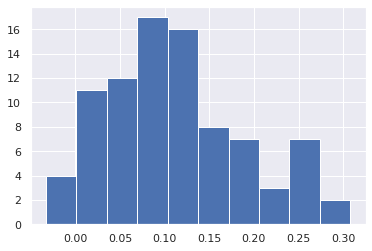

In [67]:
plt.hist(optim_diffs.values()

In [85]:
max_diff = max(optim_diffs.values())
for k, v in optim_diffs.items():
    if v == max_diff:
        print(k, v)

('29213134', 2) 0.3079483484110984


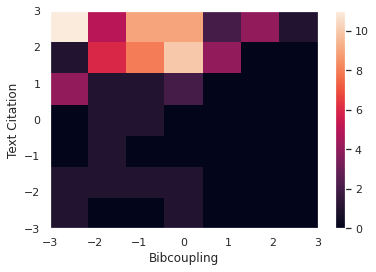

In [77]:
import math

plt.hist2d([math.log2(x) for x in optim_bibcoupling], 
           [math.log2(x) for x in optim_text_citation],
           bins=(7, 7))
plt.xlabel('Bibcoupling')
plt.ylabel('Text Citation')
plt.colorbar()

In [95]:
results_df

26580716  \
                                                            1   
best_score                                           0.458716   
best_soi                                            (1, 1, 4)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                               \
                                                            2   
best_score                                           0.469872   
best_soi                                            (1, 1, 4)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                     26580717  \
                                                            1   
best_score                                           0.480085   
best_soi                                            (1, 1, 4)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                               \
                                                            2   
best_score                                           0.527895   
best_soi                                            (1, 1, 8)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                     26656254  \
                                                            1   
best_score                                           0.422354   
best_soi                                            (2, 1, 8)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                               \
                                                            2   
best_score                                           0.572587   
best_soi                                     (0.125, 1, 0.25)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                     26667849  \
                                                            1   
best_score                                           0.473539   
best_soi                                          (0.5, 1, 4)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                               \
                                                            2   
best_score                                           0.473539   
best_soi                                          (0.5, 1, 4)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                     26675821  \
                                                            1   
best_score                                           0.326063   
best_soi                                            (1, 1, 8)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                               ...  \
                                                            2  ...   
best_score                                            0.46357  ...   
best_soi                                         (0.25, 1, 8)  ...   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....  ...   

                                                     31937935  \
                                                            3   
best_score                                           0.494102   
best_soi                                            (1, 1, 4)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                     32005979  \
                                                            1   
best_score                                           0.476234   
best_soi                                            (1, 1, 2)   
grid        {(0.125, 1, 0.125): {'adjusted_rand_score': 0....   

                                                               \
                                                   

## Understanding Text Similarity

In [5]:
analysis_file = os.path.join(PUBTRENDS_EXPORT_FOLDER, f'28003656.json.gz')
analyzer = reload_exported_analyzer(analysis_file)

In [6]:
PUB_DF_COLUMNS = ['id', 'title', 'abstract', 'year', 'type', 'keywords', 'mesh', 'doi', 'aux']
analyzer.pub_df = analyzer.df[PUB_DF_COLUMNS]

In [7]:
settings = AnalyzerSettings()
analyzer.corpus_ngrams, analyzer.corpus_counts = \
    vectorize_corpus(analyzer.pub_df,
                     max_features=settings.VECTOR_WORDS, n_gram=settings.VECTOR_NGRAMS,
                     min_df=settings.VECTOR_MIN_DF, max_df=settings.VECTOR_MAX_DF)

In [13]:
tfidf = compute_tfidf(analyzer.corpus_counts)

In [30]:
analyzer.corpus_counts

<500x1244 sparse matrix of type '<class 'numpy.int64'>'
	with 29254 stored elements in Compressed Sparse Row format>

In [14]:
tfidf.shape

(500, 1244)

In [27]:
texts_similarity = analyzer.analyze_texts_similarity(analyzer.pub_df, tfidf,
                                                     settings.SIMILARITY_TEXT_MIN,
                                                     settings.SIMILARITY_TEXT_CITATION_N)

In [28]:
text_citations = {}

pids = list(analyzer.df['id'])
for i, pid1 in enumerate(analyzer.df['id']):
    elements = []
    while not texts_similarity[i].empty():
        similarity, j = texts_similarity[i].get()
        elements.append((similarity, pids[j]))
    text_citations[pid1] = elements

In [54]:
pid_ids = {pid: i for i, pid in enumerate(pids)}
for pid1, cit_list in text_citations.items():
    for el in cit_list:
        similarity, pid2 = el
        id1 = pid_ids[pid1]
        id2 = pid_ids[pid2]
        tfidf1 = tfidf[id1, :]
        tfidf2 = tfidf[id2, :]
        common_indices = set(tfidf1.indices).intersection(tfidf2.indices)
        n_words = tfidf.shape[1]
        print(similarity, pid, pid2)
        tfidf1 = tfidf1.toarray()
        tfidf2 = tfidf2.toarray()
        common_words = []
        for i in common_indices:
            w = tfidf1[0, i] * tfidf2[0, i]
            common_words.append((analyzer.corpus_ngrams[i], w))
        print(sorted(common_words, key=lambda el: el[1], reverse=True))
        print()

0.5722461538034544 12217171 18439825
[('bold', 0.14573139661164983), ('signal', 0.10085856487244156), ('fmri', 0.041904743706860904), ('response', 0.029566255363463675), ('lfp', 0.027877231086711775), ('neural', 0.022785574304277478), ('activity', 0.0226745471268971), ('lfps', 0.01766578085337296), ('oxygen', 0.01617637353024217), ('monkey', 0.015608610368436146), ('unit', 0.012578355642491823), ('blood', 0.012281118152088474), ('field', 0.00948921459439597), ('local', 0.008046714379390474), ('resonance', 0.007707742511015751), ('magnetic', 0.007521422985825624), ('intracortical', 0.0067198908100240765), ('visual', 0.0053868414026639975), ('correlation', 0.005237899945146374), ('site', 0.005224370054447465), ('simultaneous', 0.004796836240974298), ('contribution', 0.004703176863587027), ('potential', 0.004602199131592005), ('dependent', 0.0043947295159167616), ('type', 0.003735233577601649), ('input', 0.003735233577601649), ('recording', 0.00368312643338827), ('functional', 0.003667232

0.7701602340667569 12217171 15979027
[('pain', 0.741429184424367), ('perception', 0.0024647561734889825), ('fmri', 0.002425760815805835), ('component', 0.002346220132700333), ('region', 0.0020595477562655555), ('physiopathology', 0.0019894892867412723), ('diagnostic', 0.0019057860269261725), ('mechanism', 0.0015399457328973262), ('analysis', 0.0015024166599634655), ('subject', 0.0014552102932732173), ('regulation', 0.0013783428936432545), ('imaging', 0.0013611568347986407), ('anterior', 0.001224905979117885), ('method', 0.0012125373234716666), ('variation', 0.000991818403354835), ('prefrontal', 0.0009519921348471681), ('various', 0.0008700934943061169), ('influence', 0.0008555488590776657), ('psychological', 0.000841568814013245), ('cingulate', 0.0006263167807158685), ('cognitive', 0.0003663387115642056), ('level', 0.00036129653541723083)]

0.5604311018782202 12217171 23518223
[('adhd', 0.23710741192934875), ('task', 0.09233496726074511), ('adult', 0.043134736935912486), ('eeg', 0.0288

In [42]:
import scipy
help(scipy.sparse.csr.csr_matrix)

Help on class csr_matrix in module scipy.sparse.csr:

class csr_matrix(scipy.sparse.compressed._cs_matrix)
 |  csr_matrix(arg1, shape=None, dtype=None, copy=False)
 |  
 |  Compressed Sparse Row matrix
 |  
 |  This can be instantiated in several ways:
 |      csr_matrix(D)
 |          with a dense matrix or rank-2 ndarray D
 |  
 |      csr_matrix(S)
 |          with another sparse matrix S (equivalent to S.tocsr())
 |  
 |      csr_matrix((M, N), [dtype])
 |          to construct an empty matrix with shape (M, N)
 |          dtype is optional, defaulting to dtype='d'.
 |  
 |      csr_matrix((data, (row_ind, col_ind)), [shape=(M, N)])
 |          where ``data``, ``row_ind`` and ``col_ind`` satisfy the
 |          relationship ``a[row_ind[k], col_ind[k]] = data[k]``.
 |  
 |      csr_matrix((data, indices, indptr), [shape=(M, N)])
 |          is the standard CSR representation where the column indices for
 |          row i are stored in ``indices[indptr[i]:indptr[i+1]]`` and their
 | 